In [3]:
%%configure -f
{
    "conf": {
        "spark.pyspark.python": "python3",
        "spark.pyspark.virtualenv.enabled": "true",
        "spark.pyspark.virtualenv.type":"native",
        "spark.pyspark.virtualenv.bin.path":"/usr/bin/virtualenv"
    }
}

Starting Spark application


ID,YARN Application ID,Kind,State,Spark UI,Driver log,Current session?
1,application_1778693267920_0003,pyspark,idle,Link,Link,✔


FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

SparkSession available as 'spark'.


ID,YARN Application ID,Kind,State,Spark UI,Driver log,Current session?
1,application_1778693267920_0003,pyspark,idle,Link,Link,✔


In [5]:
sc.install_pypi_package("pandas==1.0.5", "https://pypi.org/simple")
sc.install_pypi_package("scipy==1.4.1", "https://pypi.org/simple")
sc.install_pypi_package("matplotlib==3.2.1", "https://pypi.org/simple")

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…




You are using pip version 9.0.1, however version 26.1.1 is available.
You should consider upgrading via the 'pip install --upgrade pip' command.

You are using pip version 9.0.1, however version 26.1.1 is available.
You should consider upgrading via the 'pip install --upgrade pip' command.

You are using pip version 9.0.1, however version 26.1.1 is available.
You should consider upgrading via the 'pip install --upgrade pip' command.

In [6]:
from pyspark.sql import functions as F
from pyspark.sql.functions import udf, hour, col, when
import matplotlib.pyplot as plt
import pandas as pd
from pyspark.sql.types import StringType

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [7]:
census_df = spark.read.csv(
    "s3://medicaid-poverty-analysis/medicaid-project/census_acs_2018_2024.csv",
    header=True,
    inferSchema=True
)

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [8]:
cms_df = spark.read.csv(
    "s3://medicaid-poverty-analysis/medicaid-project/cms_medicaid_2018_2024.csv",
    header=True,
    inferSchema=True
)

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [14]:
print("Census rows:", census_df.count())
census_df.printSchema()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Census rows: 19327
root
 |-- name: string (nullable = true)
 |-- total_pop: integer (nullable = true)
 |-- poverty_pop: integer (nullable = true)
 |-- total_pop_insurance: integer (nullable = true)
 |-- uninsured_pop: integer (nullable = true)
 |-- state: integer (nullable = true)
 |-- county: integer (nullable = true)
 |-- year: integer (nullable = true)
 |-- poverty_rate: double (nullable = true)
 |-- uninsured_rate: double (nullable = true)

In [13]:
print("CMS rows:", cms_df.count())
cms_df.printSchema()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

CMS rows: 4284
root
 |-- state_abbreviation: string (nullable = true)
 |-- state_name: string (nullable = true)
 |-- reporting_period: integer (nullable = true)
 |-- state_expanded_medicaid: string (nullable = true)
 |-- preliminary_or_updated: string (nullable = true)
 |-- final_report: string (nullable = true)
 |-- new_applications_submitted_to_medicaid_and_chip_agencies: integer (nullable = true)
 |-- new_applications_submitted_to_medicaid_and_chip_agencies__f_85d7: string (nullable = true)
 |-- applications_for_financial_assistance_submitted_to_the_stat_104d: integer (nullable = true)
 |-- applications_for_financial_assistance_submitted_to_the_stat_c640: string (nullable = true)
 |-- total_applications_for_financial_assistance_submitted_at_st_d6fa: integer (nullable = true)
 |-- total_applications_for_financial_assistance_submitted_at_st_9919: string (nullable = true)
 |-- individuals_determined_eligible_for_medicaid_at_application: integer (nullable = true)
 |-- individuals_determ

Since the sample size is relatively small, I decide to use the full dataset for the analysis from the start, rather than using a random sample of data.

In [17]:
# select columns to use
cms_select = cms_df.select(
    "state_abbreviation",
    "state_name", 
    "state_expanded_medicaid",
    "total_medicaid_and_chip_determinations",
    "new_applications_submitted_to_medicaid_and_chip_agencies",
    "medicaid_and_chip_child_enrollment",
    "total_adult_medicaid_enrollment",
    "total_medicaid_and_chip_enrollment",
    "total_medicaid_enrollment",
    "total_chip_enrollment",
    "reporting_period",
    "year"
).filter(
    F.col("total_medicaid_and_chip_enrollment").isNotNull()
)

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [20]:
# group by states and year
cms_annual = cms_clean.groupBy(
    "state_abbreviation",
    "state_name",
    "state_expanded_medicaid",
    "year"
).agg(
    F.avg("total_medicaid_and_chip_enrollment").alias("avg_enrollment"),
    F.avg("total_medicaid_enrollment").alias("avg_medicaid_enrollment")
)

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

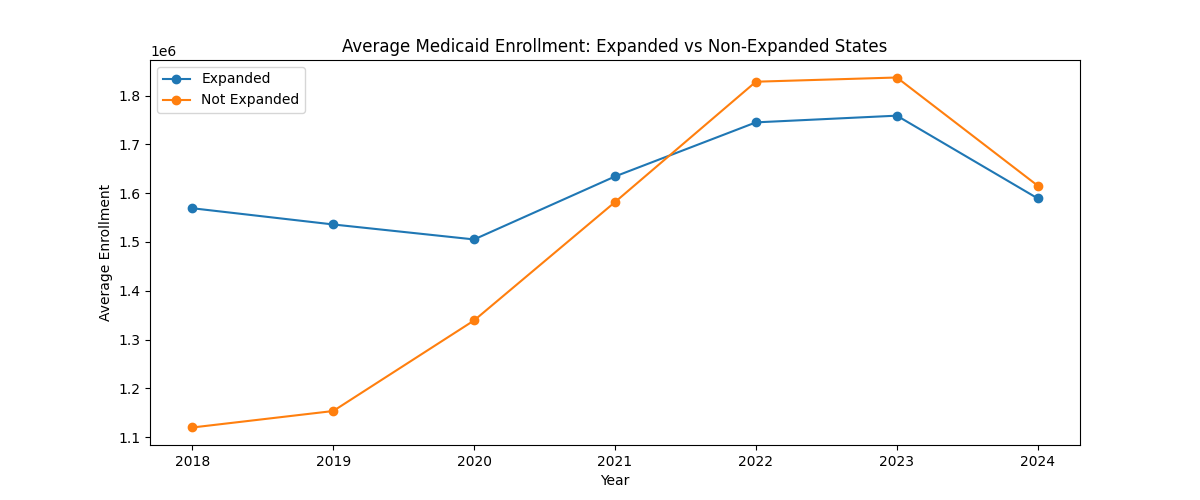

In [21]:
import matplotlib.pyplot as plt

cms_pd = cms_annual.toPandas()

# groupby expanded status
expanded = cms_pd[cms_pd['state_expanded_medicaid'] == 'Y'].groupby('year')['avg_enrollment'].mean()
not_expanded = cms_pd[cms_pd['state_expanded_medicaid'] == 'N'].groupby('year')['avg_enrollment'].mean()

plt.close()
plt.figure(figsize=(12, 5))
plt.plot(expanded.index, expanded.values, label='Expanded', marker='o')
plt.plot(not_expanded.index, not_expanded.values, label='Not Expanded', marker='o')
plt.title('Average Medicaid Enrollment: Expanded vs Non-Expanded States')
plt.xlabel('Year')
plt.ylabel('Average Enrollment')
plt.legend()
%matplot plt

In [10]:
print("CMS annual rows:", cms_annual.count())
cms_annual.show(5)

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

CMS annual rows: 363
+------------------+--------------+-----------------------+----+------------------+-----------------------+
|state_abbreviation|    state_name|state_expanded_medicaid|year|    avg_enrollment|avg_medicaid_enrollment|
+------------------+--------------+-----------------------+----+------------------+-----------------------+
|                ID|         Idaho|                      N|2019| 268142.6666666667|     242030.66666666666|
|                OH|          Ohio|                      Y|2019|        2640959.75|     2440545.3333333335|
|                SC|South Carolina|                      N|2020|         1074619.5|      976989.8333333334|
|                SC|South Carolina|                      N|2018|1039636.0833333334|      952469.6666666666|
|                MI|      Michigan|                      Y|2019|2320336.8333333335|              2256625.5|
+------------------+--------------+-----------------------+----+------------------+-----------------------+
only sh

In [11]:
# census group to state level
census_state = census_df.groupBy("state", "year").agg(
    F.sum("total_pop").alias("state_total_pop"),
    F.sum("poverty_pop").alias("state_poverty_pop"),
    F.sum("uninsured_pop").alias("state_uninsured_pop"),
    F.sum("total_pop_insurance").alias("state_total_pop_insurance")
).withColumn(
    "state_poverty_rate", F.col("state_poverty_pop") / F.col("state_total_pop")
).withColumn(
    "state_uninsured_rate", F.col("state_uninsured_pop") / F.col("state_total_pop_insurance")
)

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [12]:
print("Census state rows:", census_state.count())
census_state.show(5)

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

Census state rows: 312
+-----+----+---------------+-----------------+-------------------+-------------------------+-------------------+--------------------+
|state|year|state_total_pop|state_poverty_pop|state_uninsured_pop|state_total_pop_insurance| state_poverty_rate|state_uninsured_rate|
+-----+----+---------------+-----------------+-------------------+-------------------------+-------------------+--------------------+
|   36|2023|       19391750|          2656674|              16778|                 19674246|0.13700021916536673|8.527899874790628E-4|
|   18|2019|        6461389|           867996|              15175|                  6566575| 0.1343358216012068|0.002310945964981...|
|    8|2024|        5743216|           542093|               7872|                  5764348|0.09438840538123588|0.001365635801308318|
|   27|2022|        5574039|           516284|               5176|                  5634724|0.09262296155444912| 9.18589801381576E-4|
|    6|2019|       38535926|          5

In [13]:
fips_to_abbr = {
    1: 'AL', 2: 'AK', 4: 'AZ', 5: 'AR', 6: 'CA', 8: 'CO', 9: 'CT',
    10: 'DE', 11: 'DC', 12: 'FL', 13: 'GA', 15: 'HI', 16: 'ID', 17: 'IL',
    18: 'IN', 19: 'IA', 20: 'KS', 21: 'KY', 22: 'LA', 23: 'ME', 24: 'MD',
    25: 'MA', 26: 'MI', 27: 'MN', 28: 'MS', 29: 'MO', 30: 'MT', 31: 'NE',
    32: 'NV', 33: 'NH', 34: 'NJ', 35: 'NM', 36: 'NY', 37: 'NC', 38: 'ND',
    39: 'OH', 40: 'OK', 41: 'OR', 42: 'PA', 44: 'RI', 45: 'SC', 46: 'SD',
    47: 'TN', 48: 'TX', 49: 'UT', 50: 'VT', 51: 'VA', 53: 'WA', 54: 'WV',
    55: 'WI', 56: 'WY', 72: 'PR'
}

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [15]:
fips_udf = udf(lambda x: fips_to_abbr.get(x, None), StringType())

census_state = census_state.withColumn(
    "state_abbreviation", fips_udf(F.col("state"))
)

census_state.show(5)

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

+-----+----+---------------+-----------------+-------------------+-------------------------+-------------------+--------------------+------------------+
|state|year|state_total_pop|state_poverty_pop|state_uninsured_pop|state_total_pop_insurance| state_poverty_rate|state_uninsured_rate|state_abbreviation|
+-----+----+---------------+-----------------+-------------------+-------------------------+-------------------+--------------------+------------------+
|   36|2023|       19391750|          2656674|              16778|                 19674246|0.13700021916536673|8.527899874790628E-4|                NY|
|   18|2019|        6461389|           867996|              15175|                  6566575| 0.1343358216012068|0.002310945964981...|                IN|
|    8|2024|        5743216|           542093|               7872|                  5764348|0.09438840538123588|0.001365635801308318|                CO|
|   27|2022|        5574039|           516284|               5176|                